In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
filename=list(uploaded.keys())[0]
df=pd.read_csv(filename)
df.head()

Saving Advertising.csv to Advertising.csv


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [6]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
df = df.drop_duplicates()

print(df.shape)

(200, 5)


In [10]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [11]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


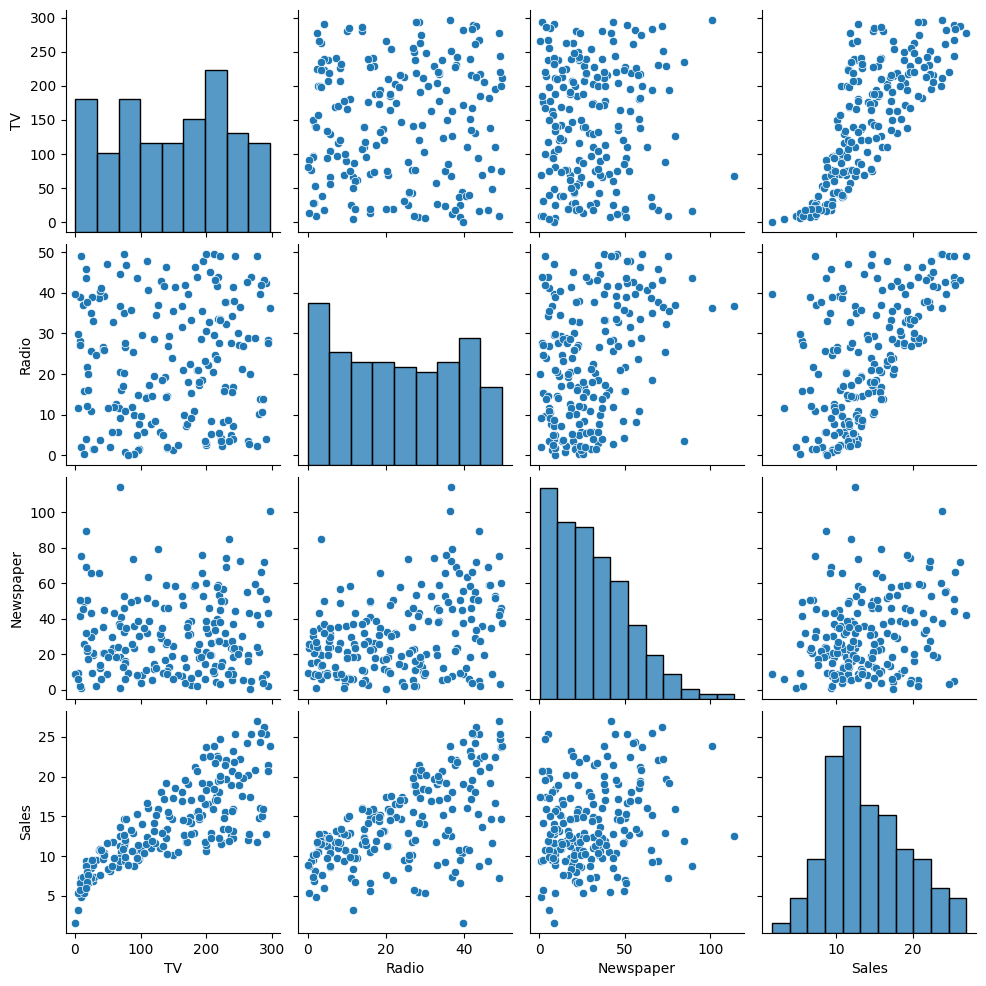

In [12]:
sns.pairplot(df)

plt.show()

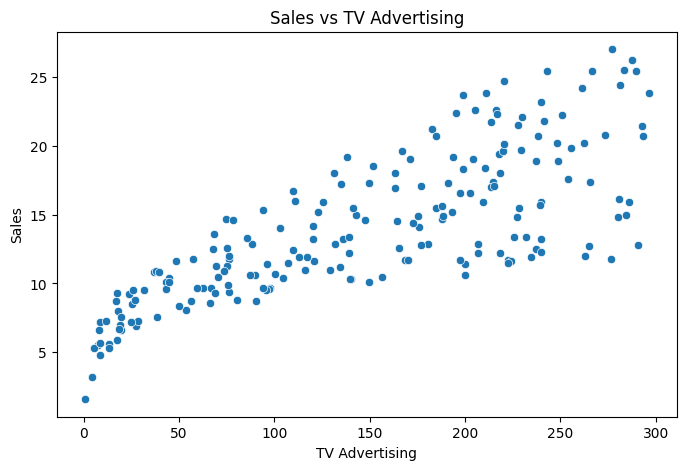

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["TV"],
    y=df["Sales"]
)

plt.title("Sales vs TV Advertising")

plt.xlabel("TV Advertising")

plt.ylabel("Sales")

plt.show()

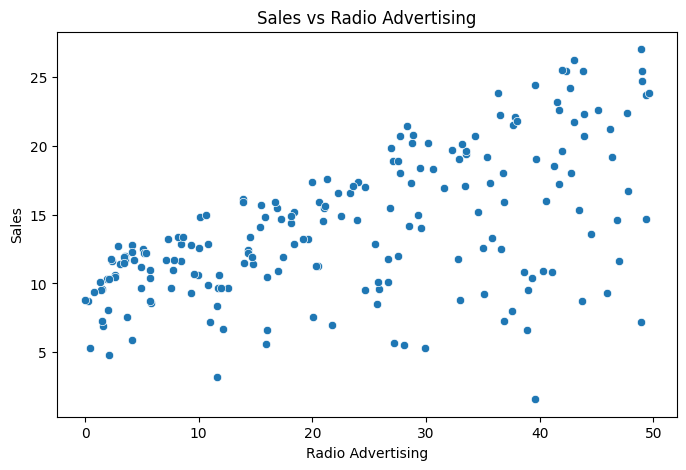

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Radio"],
    y=df["Sales"]
)

plt.title("Sales vs Radio Advertising")

plt.xlabel("Radio Advertising")

plt.ylabel("Sales")

plt.show()

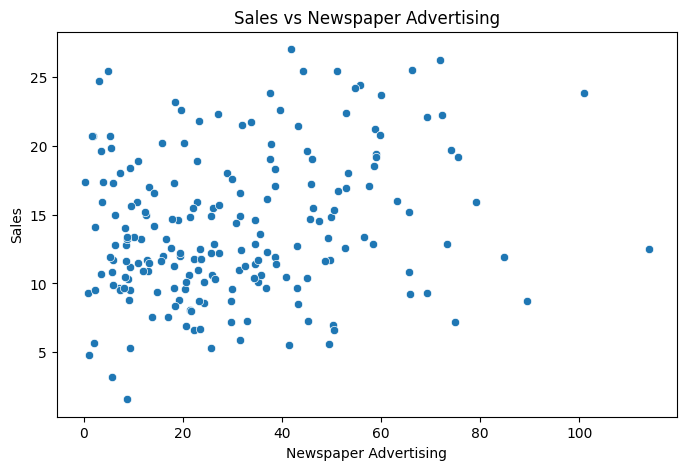

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Newspaper"],
    y=df["Sales"]
)

plt.title("Sales vs Newspaper Advertising")

plt.xlabel("Newspaper Advertising")

plt.ylabel("Sales")

plt.show()

In [16]:
correlation = df.corr()

print(correlation)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


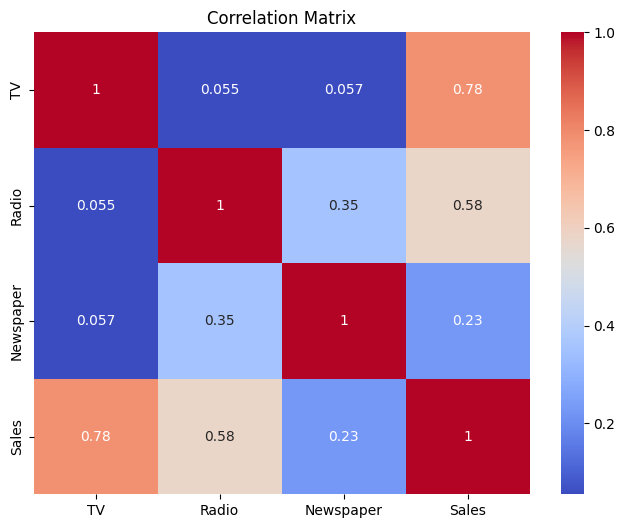

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
X = df[["TV", "Radio", "Newspaper"]]

In [20]:
y = df["Sales"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (160, 3)
Testing Samples : (40, 3)


In [22]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [23]:
linear_predictions = linear_model.predict(
    X_test
)

linear_predictions[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [24]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")

print("MAE :", linear_mae)

print("RMSE :", linear_rmse)

print("R² Score :", linear_r2)

Linear Regression Performance
MAE : 1.4607567168117603
RMSE : 1.78159966153345
R² Score : 0.899438024100912


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [26]:
rf_predictions = rf_model.predict(
    X_test
)

rf_predictions[:10]

array([17.7615, 21.6665, 20.6595,  6.7395, 23.096 , 13.5155, 22.486 ,
        9.6625, 11.8545, 15.504 ])

In [27]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R² Score :", rf_r2)

Random Forest Performance
MAE : 0.6287125000000021
RMSE : 0.7572349907723515
R² Score : 0.9818333477552758


In [28]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628713,0.757235,0.981833


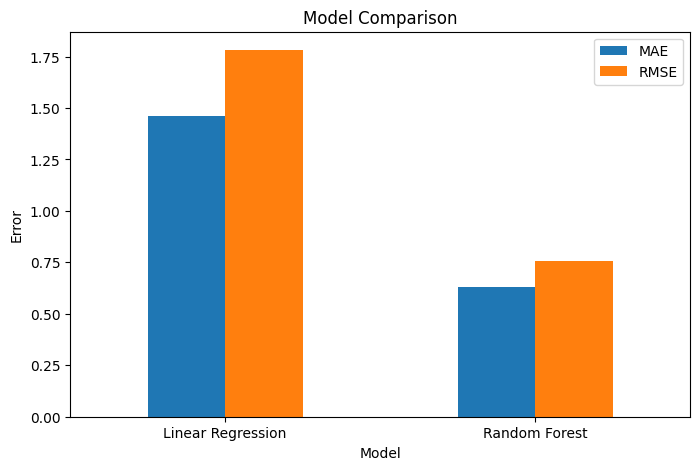

In [29]:
results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.show()

In [30]:
if rf_r2 > linear_r2:
    best_model = rf_model
    best_predictions = rf_predictions
    best_model_name = "Random Forest"
else:
    best_model = linear_model
    best_predictions = linear_predictions
    best_model_name = "Linear Regression"

print("Best Model :", best_model_name)

Best Model : Random Forest


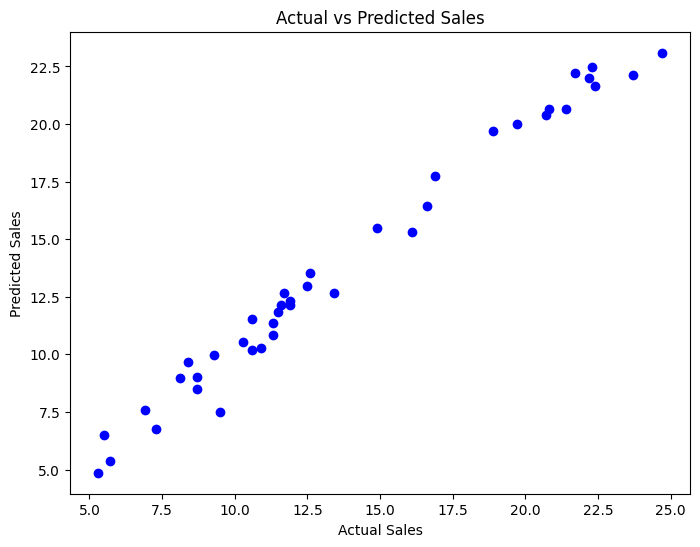

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    color="blue"
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [32]:
residuals = y_test - best_predictions

residuals.head()

,Sales
95,-0.8615
15,0.7335
30,0.7405
158,0.5605
128,1.6040


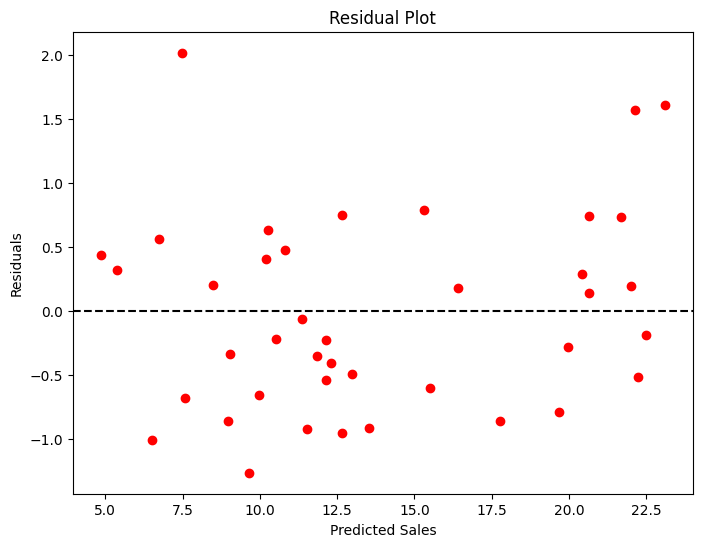

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    best_predictions,
    residuals,
    color="red"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [34]:
coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": linear_model.coef_

})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [35]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


In [36]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


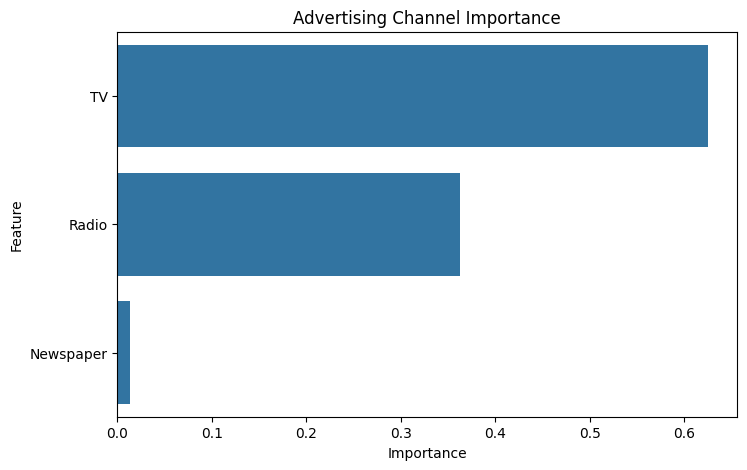

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Advertising Channel Importance")

plt.show()

In [38]:
highest = feature_importance.iloc[0]

print("Highest Impact Advertising Channel")

print("------------------------------")

print("Channel :", highest["Feature"])

print("Importance :", highest["Importance"])

Highest Impact Advertising Channel
------------------------------
Channel : TV
Importance : 0.6247274604702653


In [39]:
import joblib

joblib.dump(
    best_model,
    "sales_prediction_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [40]:
import joblib

joblib.dump(
    best_model,
    "sales_prediction_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
import os

print(os.getcwd())

print(os.listdir())

/content
['.config', 'Advertising.csv', 'sales_prediction_model.pkl', 'sample_data']


In [42]:
loaded_model = joblib.load(
    "sales_prediction_model.pkl"
)

sample = pd.DataFrame({

    "TV":[150],

    "Radio":[25],

    "Newspaper":[20]

})

prediction = loaded_model.predict(sample)

print("Predicted Sales :", prediction[0])

Predicted Sales : 15.163499999999974


In [43]:
print("="*50)

print("SALES PREDICTION PROJECT")

print("="*50)

print()

print("Linear Regression")

print("MAE :", linear_mae)

print("RMSE :", linear_rmse)

print("R² :", linear_r2)

print()

print("Random Forest")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R² :", rf_r2)

print()

print("Best Model :", best_model_name)

print()

print("Highest Impact Advertising Channel :")

print(feature_importance.iloc[0]["Feature"])

print("="*50)

SALES PREDICTION PROJECT

Linear Regression
MAE : 1.4607567168117603
RMSE : 1.78159966153345
R² : 0.899438024100912

Random Forest
MAE : 0.6287125000000021
RMSE : 0.7572349907723515
R² : 0.9818333477552758

Best Model : Random Forest

Highest Impact Advertising Channel :
TV


In [44]:
import os

print(os.getcwd())

/content


In [45]:
print(os.listdir())

['.config', 'Advertising.csv', 'sales_prediction_model.pkl', 'sample_data']


In [46]:
from google.colab import files

files.download("sales_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>